In [1]:
import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
from torchdyn.datasets import *
from numpy.linalg import norm 
from sklearn.neighbors import NearestNeighbors
import torch.nn as nn
import time
from tqdm import tqdm
#import functorch


2024-05-02 13:27:51.397924: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /cvmfs/ai.mila.quebec/apps/arch/distro/OpenSSL/1.1/lib:/cvmfs/ai.mila.quebec/apps/arch/distro/libreadline/7.0/lib:/cvmfs/ai.mila.quebec/apps/arch/distro/libffi/3.2.1/lib
2024-05-02 13:27:51.398933: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /cvmfs/ai.mila.quebec/apps/arch/distro/OpenSSL/1.1/lib:/cvmfs/ai.mila.quebec/apps/arch/distro/libreadline/7.0/lib:/cvmfs/ai.mila.quebec/apps/arch/distro/libffi/3.2.1/lib
2024-05-02 13:27:51.398944: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libr

In [2]:
import math

def four_normal_sample(n, dim, scale=1, var=1):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), math.sqrt(var) * torch.eye(dim)
    )
    centers = [
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(4), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data

def normal_sample(n, dim):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), torch.eye(dim)
    )
    return m.sample_n(n)




In [3]:
import torchdyn
from torchdyn.core import NeuralODE

class CNF(torch.nn.Module):
    def __init__(self, net, trace_estimator=None, noise_dist=None):
        super().__init__()
        self.net = net
        self.trace_estimator = trace_estimator if trace_estimator is not None else autograd_trace
        self.noise_dist, self.noise = noise_dist, None

    def forward(self, t, x):
        with torch.set_grad_enabled(True):
            x_in = x[:, 1:].requires_grad_(
                True
            )  # first dimension reserved to divergence propagation
            # the neural network will handle the data-dynamics here
            x_out = self.net(torch.cat([x_in, t * torch.ones(x.shape[0], 1)], dim=-1))
            trJ = self.trace_estimator(x_out, x_in, noise=self.noise)
        return (
            torch.cat([-trJ[:, None], x_out], 1) + 0 * x
        )  # `+ 0*x` has the only purpose of connecting x[:, 0] to autograd graph

    def backward(self, t, x):
        with torch.set_grad_enabled(True):
            x_in = x[:, 1:].requires_grad_(
                True
            )  # first dimension reserved to divergence propagation
            # the neural network will handle the data-dynamics here
            x_out = -self.net(torch.cat([x_in, t * torch.ones(x.shape[0], 1)], dim=-1))
            trJ = self.trace_estimator(x_out, x_in, noise=self.noise)
        return (
            torch.cat([-trJ[:, None], x_out], 1) + 0 * x
        )  # `+ 0*x` has the only purpose of connecting x[:, 0] to autograd graph

In [4]:
def metric(out):
    m = torch.eye(2)[None,...].repeat(out.shape[0],1,1)
    m[:,0,0] = torch.sin(out[:,1]).pow(2)
    return m

def polar_to_euc(mat):
    """mat (np.array): N X D
    N: number of observation in the path
    D: dimension (theta,psi)"""
    N, D = mat.shape
    coor = np.empty((N, 3))
    for i in range(N):
        theta, psi = mat[i, :]
        coor[i, :] = (
            np.sin(theta) * np.cos(psi),
            np.sin(theta) * np.sin(psi),
            np.cos(theta),
        )

    return coor

def euc_to_polar(mat):
    """mat (np.array) N X 3 return the corresponding polar coordinates."""
    N, _ = mat.shape
    coor = np.empty((N, 2))
    for i in range(N):
        x, y, z = mat[i, :]
        coor[i, :] = (np.arctan((np.sqrt(x**2 + y**2) / z)), np.arctan(y / x))
    return coor

In [5]:
def sphere_coor_quotient_space(x):
    x0q = torch.remainder(x[:, 0], 2 * torch.pi)
    #x0q = torch.where(x0q > torch.pi, x0q - 2 * torch.pi, x0q)
    
    x1q = torch.remainder(x[:, 1],  torch.pi)
    #x1q = torch.where(x1q > torch.pi, x1q - torch.pi, x1q)
    
    x = torch.stack([x0q, x1q], dim=1)
    return x

In [6]:
import random

random.seed(10)
def generate_sphere_point_cloud(num_points, radius=1):
    theta = torch.rand(num_points) * 2 * torch.pi
    phi = torch.pi * torch.rand(num_points)

    x = radius * torch.sin(phi) * torch.cos(theta)
    y = radius * torch.sin(phi) * torch.sin(theta)
    z = radius * torch.cos(phi)

    return torch.stack([x, y, z], dim = 1)

# Generate a sphere point cloud with 1000 points and radius 1
cloud = generate_sphere_point_cloud(5000, radius=1)



In [7]:
def sample_from_cloud(X, query, k):
    nbrs =NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(X)
    idx = nbrs.kneighbors(query, k, return_distance=False)
    return X[idx]

In [8]:
def generate_sphere_latent(num_points):
    theta = torch.rand(num_points) * 2 * torch.pi
    phi = torch.pi * torch.rand(num_points)

    return torch.stack([theta, phi], dim = 1)
X = generate_sphere_latent(5000)

In [9]:
#X0 = torch.tensor([[np.pi/5, np.pi/4]])
#X1 = torch.tensor([[2* np.pi/5, 3* np.pi/4]])

X0 = torch.tensor([[4.8367, 1.5119]])
X1 = torch.tensor([[2.7707, 1.0834]])
#X0 = polar_to_euc(X0)
#X1 = polar_to_euc(X1)

batch_size = 64

X0 = sample_from_cloud(X, X0, batch_size)
X1 = sample_from_cloud(X, X1, batch_size)

#x0 = torch.tensor(euc_to_polar(x0_euc)).float()
#x1 = torch.tensor(euc_to_polar(x1_euc)).float()

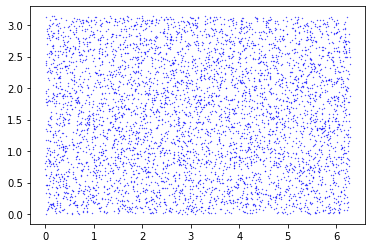

In [10]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c = 'b', s = 0.1)

#plt.scatter(x0[:, 0], x0[:, 1], c = 'r')
#plt.scatter(x1[:, 0], x1[:, 1], c = 'r')

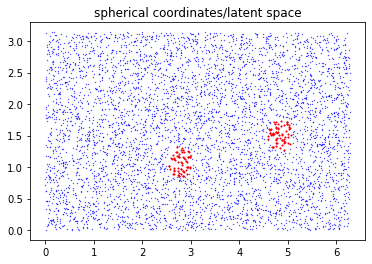

In [11]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c = 'b', s = 0.1)
plt.scatter(X0[:, 0], X0[:, 1], c = 'r', s = 1)
plt.scatter(X1[:, 0], X1[:, 1], c = 'r', s = 1)
plt.title("spherical coordinates/latent space")
plt.show()

In [12]:
def sphere_geodesic_torch(x0, x1, t):
    """|
    x0 : N x d
    x1 : N x d
    t : T

    Returns : T x N x d
    """

    vx = torch.cos(x0[:,0]) * torch.sin(x0[:,1])
    vy = torch.sin(x0[:,0]) * torch.sin(x0[:,1])
    vz = torch.cos(x0[:,1])

    wx = torch.cos(x1[:,0]) * torch.sin(x1[:,1])
    wy = torch.sin(x1[:,0]) * torch.sin(x1[:,1])
    wz = torch.cos(x1[:,1])

    v = torch.stack([vx,vy,vz],-1)
    w = torch.stack([wx,wy,wz],-1)

    u = w - ((v*w).sum(1))[:,None] * v
    u = u / torch.linalg.norm(u, dim = 1)[:,None]

    c = torch.arccos(((v*w).sum(1)))

    alpha = torch.cos(t[:,None] * c[None,:])[...,None] * v[None,:] + torch.sin(t[:,None] * c[None,:])[...,None] * u[None,:]


    v = torch.arccos(alpha[...,2])
    cosu = alpha[...,0] / torch.sin(v)
    sinu = alpha[...,1] / torch.sin(v)
    u = torch.atan2(sinu,cosu)

    return alpha , torch.stack([u,v], -1)

In [13]:
class MLP(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64, time_varying=False):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + (1 if time_varying else 0), w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [14]:
class CurveNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, x0, x1, w_envelope = 1, power = 1):
        super().__init__()
        self.mod = nn.Sequential(nn.Linear(1,hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim,hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim,hidden_dim),
                    nn.ReLU(),
                    nn.Linear(hidden_dim,input_dim))
        self.x0 = x0
        self.x1 = x1
        self.w_envelope = w_envelope
        self.input_dim = input_dim
        self.power = power
    def forward(self, t):
    
        mu = t * self.x1 + (1-t) * self.x0
        
        enveloppe = self.w_envelope * (1- (t*2-1)** (2 * self.power)) #* self.mod(t)[:, self.input_dim].reshape(-1, 1)
        outs =  self.mod(t)[:,:self.input_dim] * enveloppe + mu

        return outs

In [15]:
class GeneralGroundedCurve(nn.Module):
    def __init__(self, input_dim, hidden_dim, scale_factor=5):
        super().__init__()
        self.mod = nn.Sequential(
            nn.Linear(2 * input_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )
        self.scale_factor = scale_factor

        self.input_dim = input_dim

    def forward(self, x0, x1, t):
        """
        x0 : N x d
        x1 : N x d
        t : T

        output : T x N x d
        """
        #x0_ = x0.repeat(t.shape[0], 1)
        #x1_ = x1.repeat(t.shape[0], 1)
        #t_ = torch.repeat_interleave(t, x0.shape[0], dim=0)[:, None]
    

        x = torch.cat([x0, x1, t], dim=1)
        avg = t * x1 + (1 - t) * x0
        enveloppe = self.scale_factor * (1 - (t * 2 - 1) ** 2)
        outs = self.mod(x) * enveloppe + avg

        return outs


In [16]:
batch_size = 64
x0 = X0[torch.randperm(X0.shape[0])[:batch_size]]
x1 = X1[torch.randperm(X1.shape[0])[:batch_size]]

In [17]:
use_quotient = True
if use_quotient:
    X0 = sphere_coor_quotient_space(X0)
    X1 = sphere_coor_quotient_space(X1)

## Train Geodesic Curves

In [18]:
sigma = 0.1
with_metric = True
input_dim = 2
batch_size = 64
hidden_dim = 256
w_envelope = 2
power = 1

flow_model = MLP(dim=input_dim, w = hidden_dim, time_varying=True)
#optimizer = torch.optim.Adam(model.parameters())

curve_model = GeneralGroundedCurve(input_dim, hidden_dim)
#score_model = score_action  # GradModel(score_action)
optimizer = torch.optim.Adam(list(flow_model.parameters()) + list(curve_model.parameters()), 0.001)
#optimizer = torch.optim.Adam(curve_model.parameters(), lr=0.001)

start = time.time()
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    t = torch.rand(batch_size, 1)
    x0 = X0[torch.randperm(X0.shape[0])[:batch_size]]
    x1 = X1[torch.randperm(X1.shape[0])[:batch_size]]
    
    
    a, b = pot.unif(x0.size()[0]), pot.unif(x1.size()[0])
    M = torch.cdist(x0, x1) ** 2
    M = M / M.max()
    pi = pot.emd(a, b, M.detach().cpu().numpy())
    p = pi.flatten()
    p = p / p.sum()
    choices = np.random.choice(pi.shape[0] * pi.shape[1], p=p, size=batch_size)
    i, j = np.divmod(choices, pi.shape[1])
    
    if with_metric:
     
        out = curve_model(x0[i], x1[j],t)
        jac = torch.autograd.functional.jacobian(curve_model.forward, (x0[i], x1[j], t),create_graph=True)[2]
        
        dx1_dt = jac[:, 0, :, 0].diagonal(dim1=0, dim2=1)
        dx2_dt = jac[:, 1, :, 0].diagonal(dim1=0, dim2=1)
        jac = torch.stack((dx1_dt, dx2_dt), dim=1)
        #jac = torch.einsum("tntd->tnd",jac)[...,0]

        m = metric(out)
            
        pre_prod = torch.einsum('tb,tbj->tj',jac,m)
        prod = torch.einsum('tb,tb->t', pre_prod, jac)
        #prod = torch.mean(torch.bmm(torch.bmm(jac.unsqueeze(1), m), jac.unsqueeze(2)))
        loss_traj = prod.mean()
        
        vt = flow_model(torch.cat([out, t], dim=-1))

        v_loss = torch.mean((vt - jac) ** 2)
        loss = v_loss + loss_traj 
        #loss = loss_traj
        
        #loss.backward()
        #optimizer.step()
        #loss_traj_all.append(loss_traj.detach().numpy())
        #jac_all.append(jac)
        #indx = np.argmin(loss_traj_all)
        #jac_all = torch.stack(jac_all)
        #best_jac = jac_all[indx]

        #x = curve(t)
        
    
 
    else: 
        mu_t = t * x1[j] + (1 - t) * x0[i]
        sigma_t = sigma *  (1- (t*2-1)** 2) #torch.sqrt(t - t**2)
        x = mu_t + sigma_t * torch.randn_like(x0[i])
        sigma_t_prime_over_sigma_t = (- 4 * (2*t -1)) #(1 - 2 * t) / (2 * t * (1 - t))
        ut = sigma_t_prime_over_sigma_t * (x - mu_t) + x1[j] - x0[i]
        vt = flow_model(torch.cat([x, t], dim=-1))
    
        alpha = 0
        beta = 1
    
        metrics = metric(x)
        len_loss = torch.mean(torch.bmm(torch.bmm(vt.unsqueeze(1), metrics), vt.unsqueeze(2)))
        v_loss = torch.mean((vt - ut) ** 2) 
        loss = alpha * len_loss + beta * v_loss
    
    
    loss.backward()
    #     print(loss.item())
    optimizer.step()
    if epoch % 500 == 0:
        end = time.time()
        print(f"{epoch}: loss {loss.item():0.3f} time {(end - start) / 100:0.2f}")
        start = end
        continue



  2%|▏         | 2/100 [00:00<00:25,  3.91it/s]

0: loss 6.069 time 0.00


100%|██████████| 100/100 [00:16<00:00,  6.04it/s]


In [19]:
t = torch.linspace(0, 1, 100)
oracle = sphere_geodesic_torch(x0[i],x1[j],t)[1]

In [20]:
in_quotient = []
for l in range(100):
    qq = sphere_coor_quotient_space(oracle[l])
    in_quotient.append(qq)
oracle = np.stack(in_quotient)

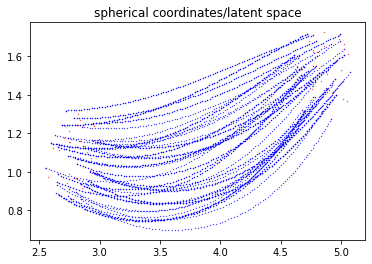

In [21]:
plt.figure()
#plt.scatter(X[:, 0], X[:, 1], c = 'b', s = 0.1)
plt.scatter(x0[:, 0], x0[:, 1], c = 'r', s = 0.1)
plt.scatter(x1[:, 0], x1[:, 1], c = 'r', s = 0.1)
plt.scatter(oracle[:,:, 0], oracle[:,:, 1], c = 'b', s = 0.1)
plt.title("spherical coordinates/latent space")
plt.show()

In [22]:
x0 = X0[torch.randperm(X0.shape[0])[:batch_size]]
x1 = X1[torch.randperm(X1.shape[0])[:batch_size]]

a, b = pot.unif(x0.size()[0]), pot.unif(x1.size()[0])
M = torch.cdist(x0, x1) ** 2
M = M / M.max()
pi = pot.emd(a, b, M.detach().cpu().numpy())
p = pi.flatten()
p = p / p.sum()
choices = np.random.choice(pi.shape[0] * pi.shape[1], p=p, size=batch_size)
i, j = np.divmod(choices, pi.shape[1])
out_all = []
for k in range(100):
    t = torch.tensor([0.01 * k]).repeat(batch_size, 1)
    out = curve_model(x0[i], x1[j],t)
    out_all.append(out)
    

In [23]:
pred = torch.stack(out_all).detach().numpy()

In [24]:
#torch.save(model, "fm_model_v8_big_moon_ot.pt")

In [25]:
#model = torch.load("fm_model_v8_big_moon_ot.pt")

In [31]:
class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))

node = NeuralODE(
    torch_wrapper(flow_model), solver="dopri5", sensitivity="adjoint", atol=1e-1, rtol=1e-1
)
dim = 2
sample_size = 64
x0 = X0[torch.randperm(X0.shape[0])[:sample_size]]
flow_traj = (
    node.trajectory(
        x0,
        t_span=torch.linspace(0, 1, 100),
    )
    .detach()
    .cpu()
)


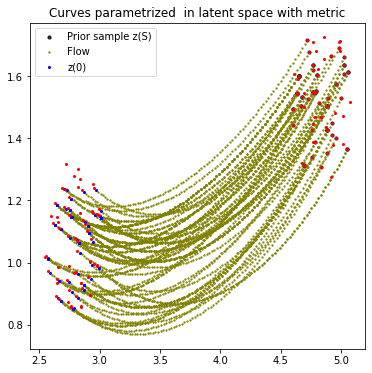

In [29]:

traj = pred
n = 2000
plt.figure(figsize=(6, 6))
plt.scatter(traj[0, :, 0], traj[0, :, 1], s=10, alpha=0.8, c="black")
plt.scatter(traj[:, :, 0], traj[:, :, 1], s=2, alpha=0.8, c="olive")
plt.scatter(traj[-1, :, 0], traj[-1, :, 1], s=4, alpha=1, c="blue")
plt.scatter(x0[:, 0], x0[:, 1], s=4, alpha=1, c="r")
plt.scatter(x1[:, 0], x1[:, 1], s=4, alpha=1, c="r")
#plt.plot(prediction[:,0], prediction[:,1], label = "prediction")
plt.legend(["Prior sample z(S)", "Flow", "z(0)"])
plt.title("Curves parametrized  in latent space with metric")
plt.show()

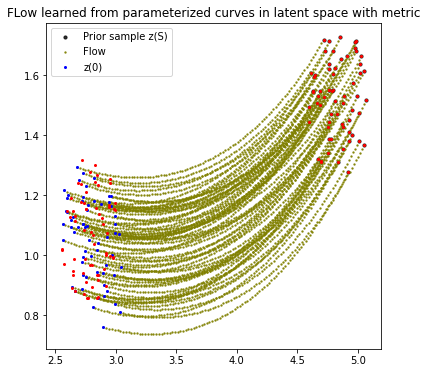

In [33]:
traj = pred
n = 2000
plt.figure(figsize=(6, 6))
plt.scatter(flow_traj[0, :, 0], flow_traj[0, :, 1], s=10, alpha=0.8, c="black")
plt.scatter(flow_traj[:, :, 0], flow_traj[:, :, 1], s=2, alpha=0.8, c="olive")
plt.scatter(flow_traj[-1, :, 0], flow_traj[-1, :, 1], s=4, alpha=1, c="blue")
plt.scatter(x0[:, 0], x0[:, 1], s=4, alpha=1, c="r")
plt.scatter(x1[:, 0], x1[:, 1], s=4, alpha=1, c="r")
#plt.plot(prediction[:,0], prediction[:,1], label = "prediction")
plt.legend(["Prior sample z(S)", "Flow", "z(0)"])
plt.title("FLow learned from parameterized curves in latent space with metric")
plt.show()

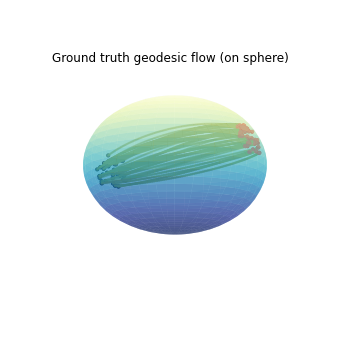

In [27]:
#oracle = sphere_geodesic_torch(x0[i],x1[j],t)[1]
traj = oracle

#plt.rcParams["figure.figsize"] = [7.00, 3.50]
#plt.rcParams["figure.autolayout"] = True
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')
r = 0.05
u, v = np.mgrid[0:2 * np.pi:30j, 0:np.pi:30j]
x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)
ax.plot_surface(x, y, z, cmap=plt.cm.YlGnBu_r, alpha = 0.5)

u_pred = traj[:, :, 0]
v_pred = traj[:, :, 1]

#u_pred = oracle[:, :, 0]
#v_pred = oracle[:, :, 1]

#u_pred = torch.remainder(u_pred, 2* torch.pi)
#v_pred = torch.remainder(v_pred, torch.pi)

x_pred = np.cos(u_pred) * np.sin(v_pred)
y_pred = np.sin(u_pred) * np.sin(v_pred)
z_pred = np.cos(v_pred)


ax.scatter(x_pred[0],y_pred[0],z_pred[0],c="black", s = 10, alpha = 1, label = "Source Distribution")
ax.scatter(x_pred,y_pred,z_pred,c="olive", s = 2, alpha = 0.5, label = "Flow")


ax.scatter(x_pred[-1],y_pred[-1],z_pred[-1],c="r", s = 10, alpha = 1, label = "Target Distribution")


#ax.scatter(x0_f[:, 0], x0_f[:, 1], x0_f[:, 2], c = 'black', s =10, alpha = 1, label = "Source Distribution")
#ax.scatter(x1_f[:, 0], x1_f[:, 1], x1_f[:, 2], c = 'r', s =10, alpha = 1, label = "Target Distribution")
#ax.scatter(x11[:, 0], x11[:, 1], x11[:, 2], c = 'b', s =90)

ax.view_init(-10, 50)

ax.set_title("Ground truth geodesic flow (on sphere)", y=0.95, pad=-14)

#plt.legend()
plt.axis('off')
#plt.savefig('flow_geodesic_gt.png')
plt.show()

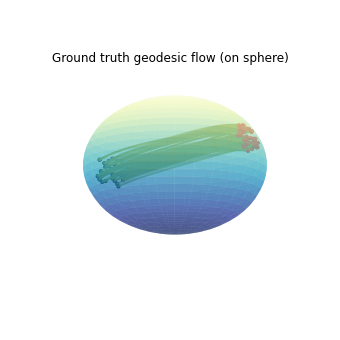

In [28]:
#oracle = sphere_geodesic_torch(x0[i],x1[j],t)[1]
traj = pred

#plt.rcParams["figure.figsize"] = [7.00, 3.50]
#plt.rcParams["figure.autolayout"] = True
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')
r = 0.05
u, v = np.mgrid[0:2 * np.pi:30j, 0:np.pi:30j]
x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)
ax.plot_surface(x, y, z, cmap=plt.cm.YlGnBu_r, alpha = 0.5)

u_pred = traj[:, :, 0]
v_pred = traj[:, :, 1]

#u_pred = oracle[:, :, 0]
#v_pred = oracle[:, :, 1]

#u_pred = torch.remainder(u_pred, 2* torch.pi)
#v_pred = torch.remainder(v_pred, torch.pi)

x_pred = np.cos(u_pred) * np.sin(v_pred)
y_pred = np.sin(u_pred) * np.sin(v_pred)
z_pred = np.cos(v_pred)


ax.scatter(x_pred[0],y_pred[0],z_pred[0],c="black", s = 10, alpha = 1, label = "Source Distribution")
ax.scatter(x_pred,y_pred,z_pred,c="olive", s = 2, alpha = 0.5, label = "Flow")


ax.scatter(x_pred[-1],y_pred[-1],z_pred[-1],c="r", s = 10, alpha = 1, label = "Target Distribution")


#ax.scatter(x0_f[:, 0], x0_f[:, 1], x0_f[:, 2], c = 'black', s =10, alpha = 1, label = "Source Distribution")
#ax.scatter(x1_f[:, 0], x1_f[:, 1], x1_f[:, 2], c = 'r', s =10, alpha = 1, label = "Target Distribution")
#ax.scatter(x11[:, 0], x11[:, 1], x11[:, 2], c = 'b', s =90)

ax.view_init(-10, 50)

ax.set_title("Ground truth geodesic flow (on sphere)", y=0.95, pad=-14)

#plt.legend()
plt.axis('off')
#plt.savefig('flow_geodesic_gt.png')
plt.show()